In [1]:
import os.path
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import skimage as skimg
from PIL import Image

plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)

In [2]:
#get image
image_path = "astronaut.jpg"
if not os.path.isfile(image_path):
    print("Downloading astronaut image...")
    # Load astronaut image from skimage
    img = skimg.data.astronaut()
    Image.fromarray(img).save(image_path)
else:
    print("Astronaut image already exists.")

Astronaut image already exists.


Original Image Shape: (300, 300, 1)


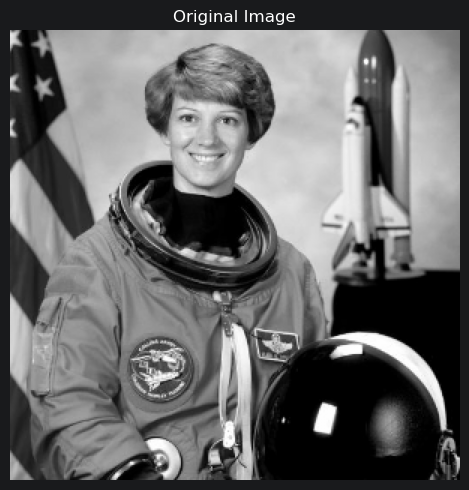

In [3]:
#load an image from skimage
image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, [300, 300])
image = tf.image.convert_image_dtype(image, tf.float32)

print("Original Image Shape:", image.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(image))
plt.title("Original Image")
plt.axis('off')
plt.show()

# Add batch dimension
image = tf.expand_dims(image, axis=0)

In [4]:
# Define convolutional kernel
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=tf.float32)
kernel = tf.reshape(kernel, [3, 3, 1, 1])
print("Kernel Shape:", kernel.shape)

Kernel Shape: (3, 3, 1, 1)


After Convolution Shape: (1, 300, 300, 1)


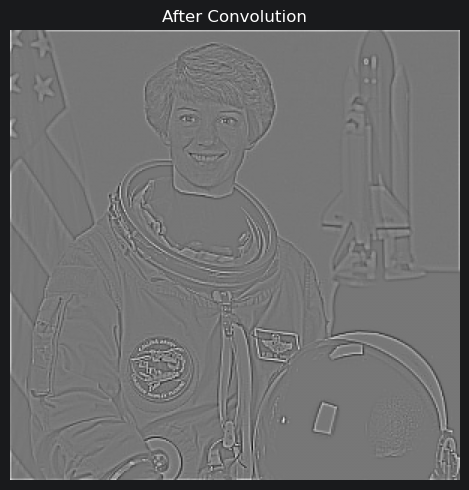

In [5]:
# Apply convolution layer
conv_output = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=[1, 1, 1, 1],
    padding='SAME'
)

print("After Convolution Shape:", conv_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(conv_output))
plt.title("After Convolution")
plt.axis('off')
plt.show()

Input shape: (1, 300, 300, 1)
SAME padding output shape: (1, 300, 300, 1)
VALID padding output shape: (1, 298, 298, 1)


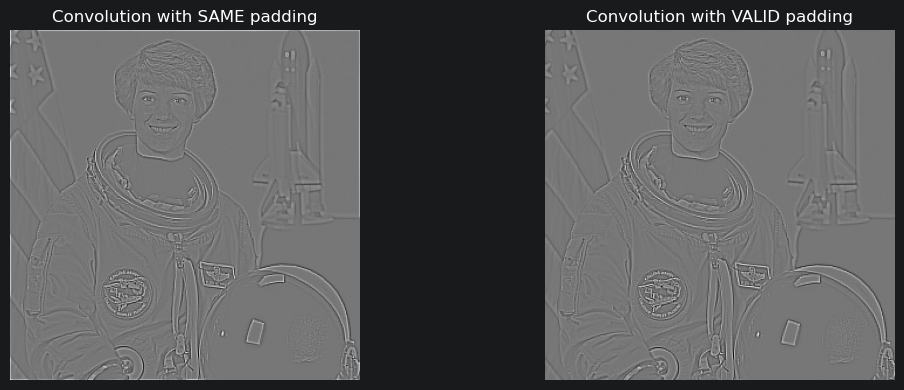

In [6]:
# Compare SAME vs VALID padding
conv_same = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=[1, 1, 1, 1],
    padding='SAME'
)

conv_valid = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=[1, 1, 1, 1],
    padding='VALID'
)

print("Input shape:", image.shape)
print("SAME padding output shape:", conv_same.shape)
print("VALID padding output shape:", conv_valid.shape)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(tf.squeeze(conv_same))
plt.title("Convolution with SAME padding")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tf.squeeze(conv_valid))
plt.title("Convolution with VALID padding")
plt.axis("off")

plt.show()

Original shape: (1, 300, 300, 1)
Padded shape: (1, 340, 340, 1)


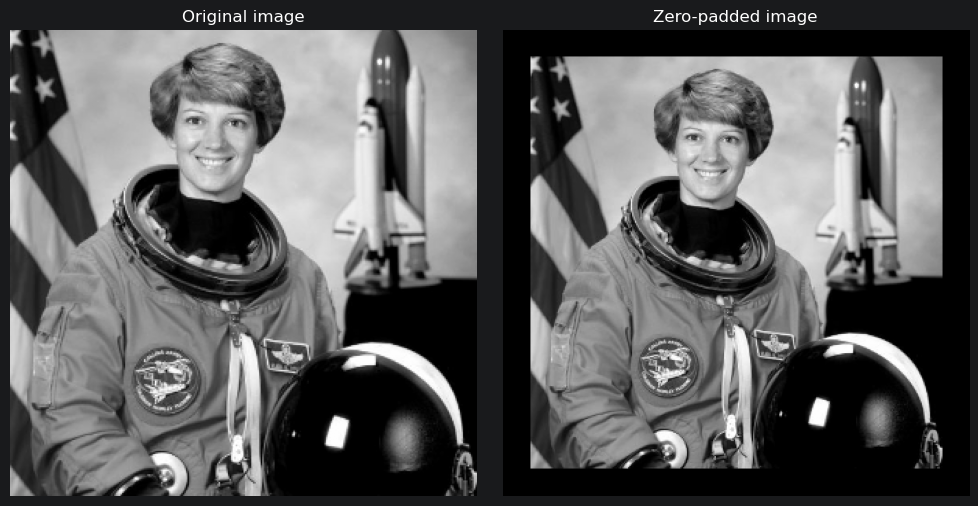

In [13]:
# Show explicit zero padding
padded_image = tf.pad(image, paddings=[[0, 0], [20, 20], [20, 20], [0, 0]], mode='CONSTANT')

print("Original shape:", image.shape)
print("Padded shape:", padded_image.shape)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(tf.squeeze(image))
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tf.squeeze(padded_image))
plt.title("Zero-padded image")
plt.axis("off")

plt.show()

Stride 1 output shape: (1, 300, 300, 1)
Stride 2 output shape: (1, 150, 150, 1)


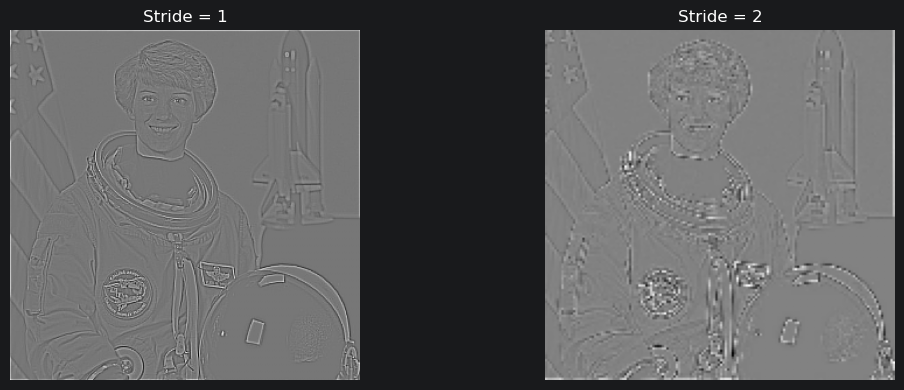

In [14]:
# Compare stride 1 vs stride 2
"""
Larger stride reduces output size.
It’s a form of downsampling.
Unlike pooling, it combines feature extraction and downsampling in one step.
"""
conv_stride1 = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=[1, 1, 1, 1],
    padding='SAME'
)

conv_stride2 = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=[1, 2, 2, 1],
    padding='SAME'
)

print("Stride 1 output shape:", conv_stride1.shape)
print("Stride 2 output shape:", conv_stride2.shape)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(tf.squeeze(conv_stride1))
plt.title("Stride = 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tf.squeeze(conv_stride2))
plt.title("Stride = 2")
plt.axis("off")

plt.show()

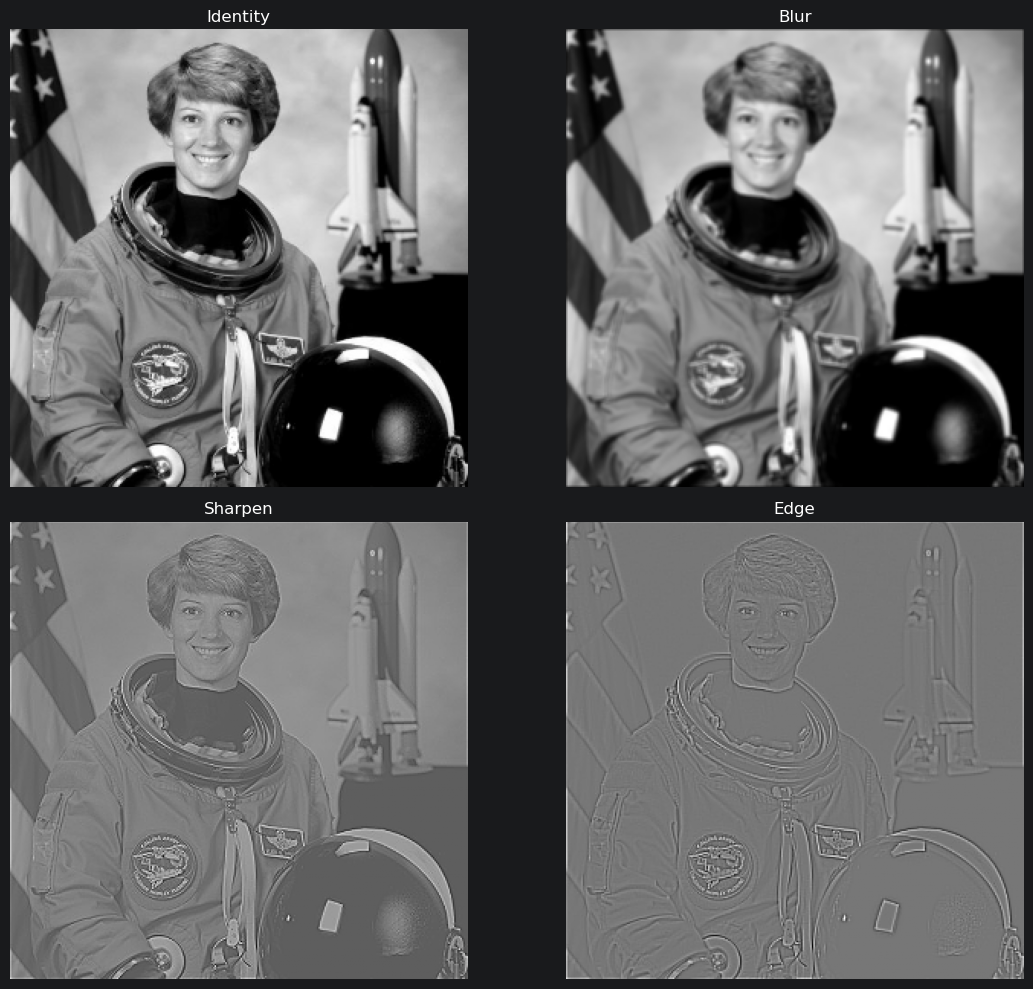

In [15]:
# Different example kernels -> Different filters detect different patterns.
identity_kernel = tf.constant([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
], dtype=tf.float32)

blur_kernel = tf.constant([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=tf.float32) / 9.0

sharpen_kernel = tf.constant([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=tf.float32)

edge_kernel = tf.constant([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
], dtype=tf.float32)

kernels = {
    "Identity": identity_kernel,
    "Blur": blur_kernel,
    "Sharpen": sharpen_kernel,
    "Edge": edge_kernel,
}

plt.figure(figsize=(12, 10))

for i, (name, k) in enumerate(kernels.items(), start=1):
    k4 = tf.reshape(k, [3, 3, 1, 1])
    out = tf.nn.conv2d(image, filters=k4, strides=[1, 1, 1, 1], padding='SAME')

    plt.subplot(2, 2, i)
    plt.imshow(tf.squeeze(out))
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

After ReLU Shape: (1, 300, 300, 1)


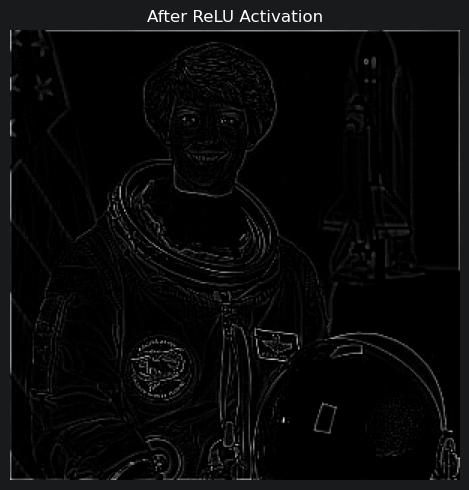

In [16]:
#apply ReLU Activation Function
relu_output = tf.nn.relu(conv_output)
sigmoid_output = tf.nn.sigmoid(conv_output)
tanh_output = tf.nn.tanh(conv_output)

print("After ReLU Shape:", relu_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(relu_output))
plt.title("After ReLU Activation")
plt.axis('off')
plt.show()

After Max Pooling Shape: (1, 150, 150, 1)


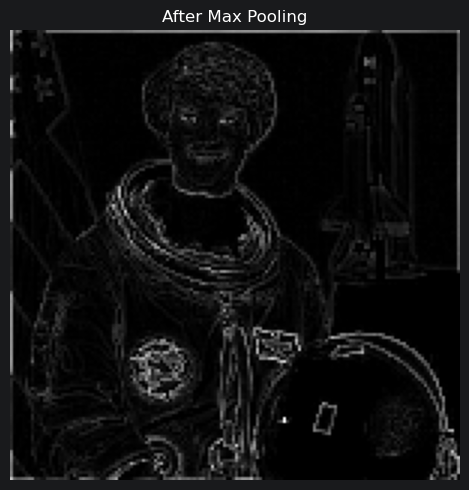

In [8]:
#apply Max Pooling
pool_output = tf.nn.max_pool2d(
    input=relu_output,
    ksize=2,
    strides=2,
    padding='SAME'
)
print("After Max Pooling Shape:", pool_output.shape)
plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(pool_output))
plt.title("After Max Pooling")
plt.axis('off')
plt.show()

After Average Pooling Shape: (1, 150, 150, 1)


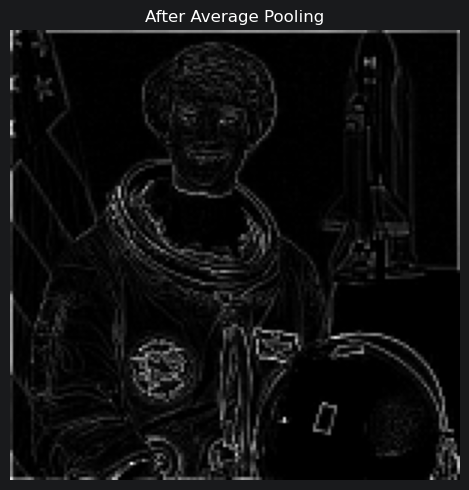

In [9]:
#apply Average Pooling
avg_pool_output = tf.nn.avg_pool2d(
    input=relu_output,
    ksize=2,
    strides=2,
    padding='SAME'
)
print("After Average Pooling Shape:", avg_pool_output.shape)
plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(avg_pool_output))
plt.title("After Average Pooling")
plt.axis('off')
plt.show()

In [10]:
#Apply Flattening Layer
flatten_layer = tf.keras.layers.Flatten()
flatten_output = flatten_layer(pool_output)

print("After Flatten Shape:", flatten_output.shape)

print("First 20 Flattened Values:")
print(flatten_output.numpy()[0][:20])

After Flatten Shape: (1, 22500)
First 20 Flattened Values:
[728.35016   245.28253   452.93674   337.2563      0.         14.2733345
  57.65235    62.57112    44.3565    177.0228    134.72699   180.97931
 479.44366   461.86447   484.1186    478.13367   486.00793   476.1836
 473.1297    479.70062  ]


In [11]:
#Add Fully Connected (Dense) Layer
dense_layer = tf.keras.layers.Dense(
    units=64,
    activation='relu'
)

dense_output = dense_layer(flatten_output)

print("After Fully Connected Layer Shape:", dense_output.shape)

After Fully Connected Layer Shape: (1, 64)


In [12]:
dense_output

<tf.Tensor: shape=(1, 64), dtype=float32, numpy=
array([[369.3053   ,   0.       ,  22.685486 , 123.06973  ,   0.       ,
        421.45908  ,   0.       ,   0.       , 135.39815  ,   0.       ,
          0.       ,   0.       ,   0.       , 177.50471  , 103.83984  ,
          0.       ,   0.       ,  99.25868  ,   0.       , 176.2728   ,
          0.       ,   0.       ,   0.       ,   0.       , 181.46347  ,
        191.93987  ,   0.       , 195.09917  ,   0.       ,   0.       ,
        205.40042  , 120.43722  ,   0.       ,   0.       ,  60.14529  ,
        106.23799  ,  16.920624 ,  23.09029  ,   0.       ,  87.97533  ,
          0.       ,   0.       , 118.12584  ,   0.       , 210.13008  ,
         56.65194  ,  68.82224  ,  97.669334 ,   0.       ,  43.630295 ,
          0.       ,  79.10818  ,   0.       , 109.082954 ,   6.5816994,
          0.       ,   0.       ,   0.       ,  27.740347 ,   0.       ,
          0.       ,   0.       , 167.83041  ,  99.6268   ]],
      dtype=f

Keras Conv2D output shape: (1, 300, 300, 4)


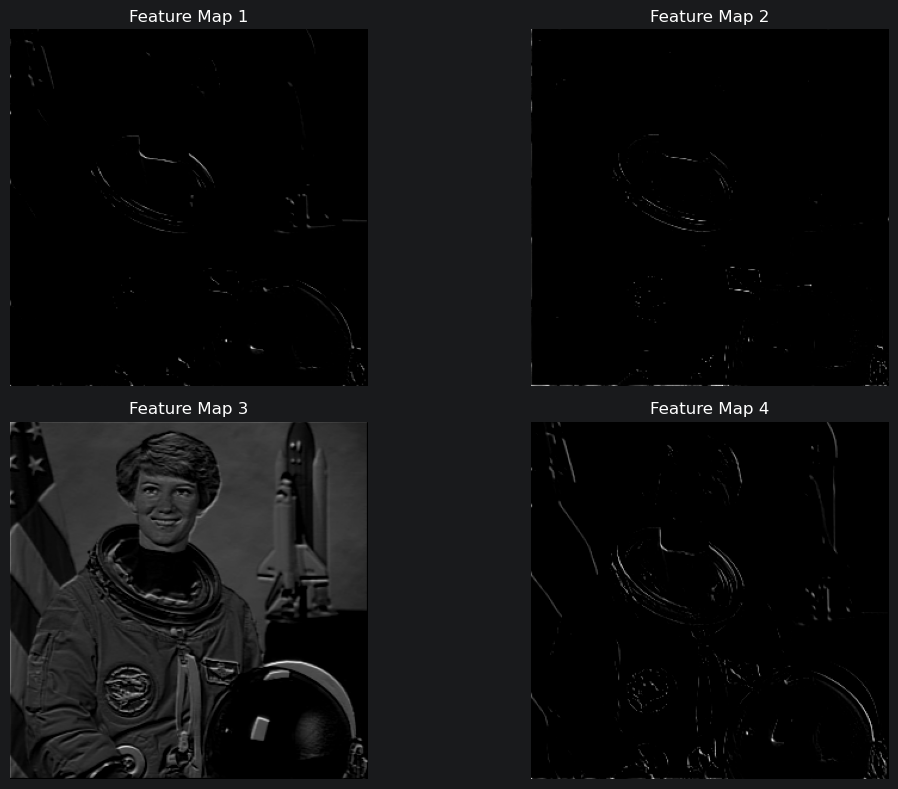

In [19]:
# Example using a Keras Conv2D layer
"""
In real CNNs:
    filters are learned
    multiple channels are produced
    each channel captures something different
"""
conv_layer = tf.keras.layers.Conv2D(
    filters=4,
    kernel_size=(3, 3),
    strides=(1, 1),
    padding='same',
    activation='relu'
)

keras_conv_output = conv_layer(image)

print("Keras Conv2D output shape:", keras_conv_output.shape)

plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(keras_conv_output[0, :, :, i], cmap='gray')
    plt.title(f"Feature Map {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

BatchNorm output shape: (1, 300, 300, 1)


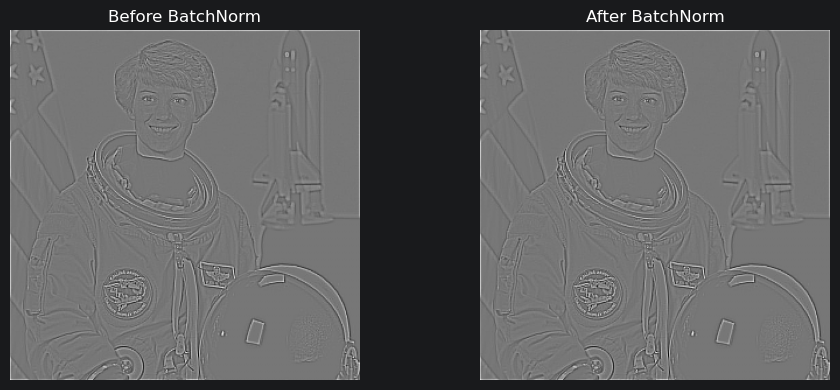

In [20]:
# Batch Normalization example
bn_layer = tf.keras.layers.BatchNormalization()

bn_output = bn_layer(conv_output, training=True)

print("BatchNorm output shape:", bn_output.shape)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(tf.squeeze(conv_output))
plt.title("Before BatchNorm")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tf.squeeze(bn_output))
plt.title("After BatchNorm")
plt.axis("off")

plt.show()